# ILLM — Lab 3: BPE and WordPiece tokenization on IndicCorp v2

**Language:** Gujarati (`guj_Gujr`). Change `LANGUAGE` in the config cell for any other IndicCorp v2 language.

### What the assignment requires

1. **Splits** — dev and test of **exactly 1000 sentences each**, built so they are *not* all of
   similar length; everything else is training data. Rows in IndicCorp v2 are **paragraphs**, so
   they must be sentence-tokenised first.
2. **BPE and WordPiece** trained on the training data, then used to tokenise dev and test.
3. **Four training-data sizes** — 100,000 / 300,000 / 500,000 / 1,000,000 sentences.
4. **Three vocabulary sizes** — 20,000 / 30,000 / 50,000.

### This notebook is the source of truth for Labs 4 and 5

Both later assignments say to reuse *these* splits. §6 writes them to a `splits/` folder together
with a manifest recording the exact sentence counts and a content hash. Lab 4 and Lab 5 load
those files and verify the hash, so the three assignments are provably working on the same data
rather than each re-deriving something similar.

Run order: **Lab 3 → Lab 4 → Lab 5.**

In [1]:
# Lab 3 needs the HuggingFace `tokenizers` library (Rust-backed BPE/WordPiece trainers)
try:
    import tokenizers
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tokenizers"], check=True)
    import tokenizers

import os, re, gc, gzip, json, math, time, heapq, random, pickle, hashlib, unicodedata, resource
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tokenizers import Tokenizer
from tokenizers.models import BPE, WordPiece
from tokenizers.trainers import BpeTrainer, WordPieceTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import NFC

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

def rss_gb():
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6

print("tokenizers", tokenizers.__version__, "| numpy", np.__version__)

tokenizers 0.23.1 | numpy 2.1.3


In [2]:
# ==================================================================================
# CONFIGURATION
# ==================================================================================

LANGUAGE = "guj_Gujr"        # IndicCorp v2 language tag
CACHE_DIR = Path(".")
DATA_DIR = Path("data");   DATA_DIR.mkdir(exist_ok=True)
SPLIT_DIR = Path("splits"); SPLIT_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path("tokenizers_out"); MODEL_DIR.mkdir(exist_ok=True)

# "full" is the assignment specification. "quick"/"tiny" keep every code path identical
# but finish in minutes — useful while iterating. Labs 4 and 5 must use the SAME preset.
PRESET = "full"              # "full" | "quick" | "tiny"

_PRESETS = {
    "full":  dict(target=1_000_000, dev=1000, test=1000,
                  train_sizes=[100_000, 300_000, 500_000, 1_000_000],
                  vocab_sizes=[20_000, 30_000, 50_000]),
    "quick": dict(target=100_000,   dev=1000, test=1000,
                  train_sizes=[10_000, 30_000, 50_000, 98_000],
                  vocab_sizes=[8_000, 16_000, 24_000]),
    "tiny":  dict(target=5_000,     dev=200,  test=200,
                  train_sizes=[500, 1_500, 2_500, 4_600],
                  vocab_sizes=[1_000, 2_000, 4_000]),
}
_P = _PRESETS[PRESET]
TARGET_SENTENCES = _P["target"]
DEV_SIZE, TEST_SIZE = _P["dev"], _P["test"]
TRAIN_SIZES = _P["train_sizes"]
VOCAB_SIZES = _P["vocab_sizes"]

FIXED_VOCAB = VOCAB_SIZES[1]        # vocabulary held fixed while training size varies
FIXED_TRAIN = TRAIN_SIZES[-1]       # training size held fixed while vocabulary varies

# ---- sentence filtering ----------------------------------------------------------
MIN_WORDS, MAX_WORDS = 3, 200       # discard fragments and runaway lines
N_LENGTH_BUCKETS = 10               # strata used when building dev/test

# ---- tokenizer training ----------------------------------------------------------
MIN_FREQUENCY = 2
SPECIAL_TOKENS = ["[UNK]", "[PAD]", "[BOS]", "[EOS]"]

# The assignment says "implement BPE and WordPiece", so both are written from scratch in
# section 5.1 and cross-checked against the library in 5.2.
#   False -> the 4x3 experiment grid runs on the Rust `tokenizers` library (minutes)
#   True  -> the grid runs on the from-scratch Python code instead (hours at PRESET="full")
USE_SCRATCH_FOR_GRID = False

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print(f"language        : {LANGUAGE}")
print(f"preset          : {PRESET}  ->  {TARGET_SENTENCES:,} sentences total")
print(f"dev / test      : {DEV_SIZE:,} / {TEST_SIZE:,} sentences (rest = training)")
print(f"training sizes  : {', '.join(f'{s:,}' for s in TRAIN_SIZES)}")
print(f"vocab sizes     : {', '.join(f'{v:,}' for v in VOCAB_SIZES)}")
print(f"experiment A    : vocab fixed at {FIXED_VOCAB:,}")
print(f"experiment B    : training size fixed at {FIXED_TRAIN:,}")

language        : guj_Gujr
preset          : full  ->  1,000,000 sentences total
dev / test      : 1,000 / 1,000 sentences (rest = training)
training sizes  : 100,000, 300,000, 500,000, 1,000,000
vocab sizes     : 20,000, 30,000, 50,000
experiment A    : vocab fixed at 30,000
experiment B    : training size fixed at 1,000,000


## 1. Sentence tokenisation

Each row of IndicCorp v2 is a **paragraph**, so it has to be split before anything else. The
splitter breaks on sentence-final punctuation followed by whitespace:

* `।` and `॥` — danda and double danda, used across Indic scripts;
* `.`, `!`, `?`, `…` — Gujarati news text in particular uses the Latin full stop heavily.

Requiring whitespace *after* the terminator is what stops `1.5` or `રૂ.500` from being torn in
half, since there is no space inside those. A fragment shorter than `MIN_WORDS` or longer than
`MAX_WORDS` is discarded — those are almost always list markup or scraping artefacts rather than
sentences.

If `indic-nlp-library` is installed the notebook uses its rule-based splitter instead, which
additionally knows about common abbreviations. The regex fallback needs no extra dependency.

In [3]:
try:
    from indicnlp.tokenize import sentence_tokenize as _isent
    _ISO = LANGUAGE.split("_")[0][:2]          # guj_Gujr -> gu
    HAVE_INDICNLP = True
except Exception:
    HAVE_INDICNLP = False

SENT_SPLIT_RE = re.compile(r"(?<=[।॥\.\!\?…])\s+")
ZERO_WIDTH = dict.fromkeys(map(ord, "\u200b\u200c\u200d\ufeff"), None)


def sentence_tokenize(paragraph):
    """Paragraph -> list of sentences."""
    p = unicodedata.normalize("NFC", paragraph).translate(ZERO_WIDTH).strip()
    if not p:
        return []
    if HAVE_INDICNLP:
        try:
            parts = _isent.sentence_split(p, lang=_ISO)
        except Exception:
            parts = SENT_SPLIT_RE.split(p)
    else:
        parts = SENT_SPLIT_RE.split(p)
    out = []
    for s in parts:
        s = " ".join(s.split())               # collapse internal whitespace
        if s:
            out.append(s)
    return out


def acceptable(sentence):
    n = sentence.count(" ") + 1
    return MIN_WORDS <= n <= MAX_WORDS


print(f"sentence splitter: {'indic-nlp-library' if HAVE_INDICNLP else 'regex fallback'}")
demo = ("આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ. "
        "ભાવ રૂ.500 થી વધીને રૂ.1.5 લાખ થયો! શું તમે તૈયાર છો?")
print("\nPARAGRAPH:", demo)
for i, s in enumerate(sentence_tokenize(demo), 1):
    print(f"  sentence {i}: {s}")

sentence splitter: regex fallback

PARAGRAPH: આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ. ભાવ રૂ.500 થી વધીને રૂ.1.5 લાખ થયો! શું તમે તૈયાર છો?
  sentence 1: આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ.
  sentence 2: ભાવ રૂ.500 થી વધીને રૂ.1.5 લાખ થયો!
  sentence 3: શું તમે તૈયાર છો?


## 2. Building the sentence corpus

IndicCorp v2 stores one large plain-text file per language. The Hindi file is ~47 GB, and Gujarati
is comparable, so the file is never downloaded whole: an HTTP stream is opened, paragraphs are read
and split into sentences as they arrive, and the connection is closed the moment
`TARGET_SENTENCES` sentences have been collected. That is typically a few hundred MB of traffic
for a million sentences.

Two repository layouts exist for this dataset, so the loader tries both:
`data/<lang_tag>/<lang_tag>.txt` first, then the short-code path `data/<xx>.txt` from the dataset
README. The resulting sentence corpus is cached gzipped, so this runs once.

In [4]:
SHORT_CODE = {
    "asm_Beng": "as", "ben_Beng": "bn", "brx_Deva": "bd", "doi_Deva": "dg", "gom_Deva": "gom",
    "guj_Gujr": "gu", "hin_Deva": "hi", "kan_Knda": "kn", "kas_Arab": "ks", "mai_Deva": "mai",
    "mal_Mlym": "ml", "mar_Deva": "mr", "mni_Mtei": "mni", "npi_Deva": "ne", "ory_Orya": "or",
    "pan_Guru": "pa", "san_Deva": "sa", "snd_Deva": "sd", "tam_Taml": "ta", "tel_Telu": "te",
    "urd_Arab": "ur", "khasi": "kha", "santhali": "sat",
}
HF_BASE = "https://huggingface.co/datasets/ai4bharat/IndicCorpV2/resolve/main"


def candidate_urls(lang):
    urls = [f"{HF_BASE}/data/{lang}/{lang}.txt"]
    sc = SHORT_CODE.get(lang)
    if sc:
        urls.append(f"{HF_BASE}/data/{sc}.txt")
    return urls


def stream_sentences(lang, target, chunk=1 << 20):
    """Stream paragraphs, split into sentences, stop once `target` sentences are collected."""
    import requests
    headers = {}
    if os.environ.get("HF_TOKEN"):
        headers["Authorization"] = f"Bearer {os.environ['HF_TOKEN']}"

    last_err = None
    for url in candidate_urls(lang):
        try:
            print(f"GET {url}")
            r = requests.get(url, stream=True, headers=headers, timeout=120)
            r.raise_for_status()
        except Exception as e:
            print(f"  unavailable ({type(e).__name__}); trying the next layout")
            last_err = e
            continue

        out, buf, paras, t0 = [], b"", 0, time.time()
        with r:
            for block in r.iter_content(chunk_size=chunk):
                if not block:
                    continue
                buf += block
                *lines, buf = buf.split(b"\n")
                for ln in lines:
                    para = ln.decode("utf-8", errors="ignore")
                    if not para.strip():
                        continue
                    paras += 1
                    for s in sentence_tokenize(para):
                        if acceptable(s):
                            out.append(s)
                if len(out) >= target:
                    break
                if paras % 50_000 == 0:
                    print(f"  {paras:,} paragraphs -> {len(out):,} sentences "
                          f"({time.time()-t0:.0f}s)", end="\r")
        print(f"  {paras:,} paragraphs -> {len(out):,} sentences in {time.time()-t0:.0f}s")
        print(f"  sentences per paragraph: {len(out)/max(paras,1):.2f}")
        return out[:target]

    raise RuntimeError(f"Could not reach IndicCorpV2 for {lang}: {last_err}")


def sentences_from_pickle(lang, target):
    """Offline fallback: treat the Assignment-1 pickle rows as paragraphs."""
    for p in ("dataset_sentences.pkl", "/mnt/user-data/uploads/dataset_sentences.pkl"):
        if os.path.exists(p):
            with open(p, "rb") as f:
                rows = pickle.load(f)[lang]
            out = [s for para in rows for s in sentence_tokenize(para) if acceptable(s)]
            print(f"Pickle fallback: {len(rows):,} paragraphs -> {len(out):,} sentences")
            return out[:target]
    raise FileNotFoundError("dataset_sentences.pkl not found")


USE_PICKLE_FALLBACK = False      # set True to run entirely offline from the Assignment-1 pickle

CORPUS_CACHE = CACHE_DIR / f"sentences_{LANGUAGE}_{TARGET_SENTENCES}.txt.gz"

if CORPUS_CACHE.exists():
    t0 = time.time()
    with gzip.open(CORPUS_CACHE, "rt", encoding="utf-8") as f:
        sentences = [ln.rstrip("\n") for ln in f]
    print(f"Loaded {len(sentences):,} cached sentences from {CORPUS_CACHE} "
          f"({CORPUS_CACHE.stat().st_size/1e6:.0f} MB, {time.time()-t0:.1f}s)")
else:
    sentences = (sentences_from_pickle(LANGUAGE, TARGET_SENTENCES) if USE_PICKLE_FALLBACK
                 else stream_sentences(LANGUAGE, TARGET_SENTENCES))
    with gzip.open(CORPUS_CACHE, "wt", encoding="utf-8", compresslevel=6) as f:
        f.write("\n".join(sentences))
    print(f"Cached to {CORPUS_CACHE} ({CORPUS_CACHE.stat().st_size/1e6:.0f} MB)")

lengths = np.array([s.count(" ") + 1 for s in sentences], dtype=np.int32)
print(f"\nSentences : {len(sentences):,}")
print(f"Words     : {int(lengths.sum()):,}")
print(f"Length    : mean {lengths.mean():.1f} | median {np.median(lengths):.0f} | "
      f"min {lengths.min()} | p95 {np.percentile(lengths,95):.0f} | max {lengths.max()}")
print(f"RSS {rss_gb():.2f} GB\n")
for s in sentences[:3]:
    print("  •", s[:120])

GET https://huggingface.co/datasets/ai4bharat/IndicCorpV2/resolve/main/data/guj_Gujr/guj_Gujr.txt
  unavailable (HTTPError); trying the next layout
GET https://huggingface.co/datasets/ai4bharat/IndicCorpV2/resolve/main/data/gu.txt
  366,826 paragraphs -> 1,001,477 sentences in 28s
  sentences per paragraph: 2.73
Cached to sentences_guj_Gujr_1000000.txt.gz (56 MB)

Sentences : 1,000,000
Words     : 15,100,176
Length    : mean 15.1 | median 13 | min 3 | p95 32 | max 200
RSS 1.14 GB

  • આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ
  • મિથેનોલ આવ્યો ક્યાંથી?
  • આખરે ત્રણ રાજ્યોમાં મળેલ હાર પર કોંગ્રેસ અધ્યક્ષ રાહુલ ગાંધી દ્વારા પ્રથમ પ્રતિક્રિયા આપવામાં આવી છે.


## 3. Length-stratified dev / test splits

> *"Create development and test sets by taking length of sentences into account. Your development
> and test sets should not consist of sentences of similar lengths. [Hint: Pick sentences of
> different lengths by maintaining a length distribution]"*

A random sample fails this: sentence lengths are heavily right-skewed, so a random 1000 sentences
are dominated by whatever length is most common, and long sentences are barely represented.

**The bucketing has to be by length value, not by rank.** This is the subtle part. If you cut the
corpus into deciles *by rank*, every decile holds exactly 10% of the data, so drawing equally from
each decile reproduces the corpus distribution — that is random sampling with extra steps. Instead
the buckets here are **equal-width ranges of word count** (3–8 words, 9–14, 15–20, …). Those
buckets are very unequal in population, so drawing the same number from each deliberately
over-samples the rare long sentences and produces a dev/test set that genuinely spans the length
range.

The procedure:

1. bin every sentence by word count into `N_LENGTH_BUCKETS` equal-width bins, capped at the 99th
   percentile so a handful of outliers cannot stretch the bins;
2. draw an equal number from each bin for dev and test, with no overlap; if a bin is too sparse to
   supply its quota, the shortfall is redistributed to bins that still have capacity;
3. everything left becomes the training pool.

Set `STRATEGY = "proportional"` to sample in proportion to bin population instead — that preserves
the corpus length distribution exactly, which is the other defensible reading of the hint. §3.2
quantifies the difference against a random sample.

In [5]:
STRATEGY = "uniform"        # "uniform" = equal draw per length bin | "proportional"


def build_length_buckets(lengths, n_buckets):
    """Equal-WIDTH bins over word count (not equal-count quantiles — see the note above)."""
    lo = int(lengths.min())
    hi = int(np.percentile(lengths, 99))
    if hi <= lo:
        hi = int(lengths.max())
    edges = np.unique(np.linspace(lo, hi, n_buckets + 1).astype(int))
    bucket_of = np.digitize(lengths, edges[1:-1], right=False)   # 0 .. len(edges)-2
    return bucket_of.astype(np.int32), edges


def allocate(avail, need, strategy):
    """How many to draw from each bin, redistributing any shortfall to bins with capacity."""
    nb = len(avail)
    per = np.zeros(nb, dtype=int)
    if strategy == "proportional":
        want = np.floor(need * avail / max(avail.sum(), 1)).astype(int)
    else:
        want = np.full(nb, need // max((avail > 0).sum(), 1), dtype=int)
    per = np.minimum(want, avail)

    # top up whatever is still missing, from bins that still have room
    while per.sum() < need:
        room = avail - per
        if not room.any():
            break
        order = np.argsort(-room)          # take from the roomiest bins first
        progressed = False
        for i in order:
            if per.sum() >= need:
                break
            if room[i] > 0:
                per[i] += 1
                progressed = True
        if not progressed:
            break
    return per


def length_stratified_split(sentences, lengths, dev_size, test_size,
                            n_buckets=N_LENGTH_BUCKETS, strategy=STRATEGY, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(sentences)
    bucket_of, edges = build_length_buckets(lengths, n_buckets)
    nb = int(bucket_of.max()) + 1

    need = dev_size + test_size
    avail = np.bincount(bucket_of, minlength=nb)
    assert avail.sum() >= need, "corpus is too small for the requested dev+test sizes"
    per = allocate(avail, need, strategy)

    dev_idx, test_idx = [], []
    for b in range(nb):
        if per[b] == 0:
            continue
        members = np.flatnonzero(bucket_of == b)
        picked = rng.choice(members, size=per[b], replace=False)
        rng.shuffle(picked)
        half = int(round(per[b] * dev_size / need))
        dev_idx.extend(picked[:half].tolist())
        test_idx.extend(picked[half:].tolist())

    # fix any rounding drift so both sizes are exact
    while len(dev_idx) > dev_size:
        test_idx.append(dev_idx.pop())
    while len(test_idx) > test_size:
        dev_idx.append(test_idx.pop())
    assert len(dev_idx) == dev_size and len(test_idx) == test_size, (len(dev_idx), len(test_idx))

    held = np.zeros(n, dtype=bool)
    held[dev_idx] = True
    held[test_idx] = True
    return np.flatnonzero(~held), np.array(sorted(dev_idx)), np.array(sorted(test_idx)), bucket_of, edges


train_idx, dev_idx, test_idx, bucket_of, bucket_edges = length_stratified_split(
    sentences, lengths, DEV_SIZE, TEST_SIZE)

train_sents = [sentences[i] for i in train_idx]
dev_sents   = [sentences[i] for i in dev_idx]
test_sents  = [sentences[i] for i in test_idx]

assert not (set(dev_idx.tolist()) & set(test_idx.tolist())), "dev and test overlap"
assert len(train_sents) + len(dev_sents) + len(test_sents) == len(sentences)

print("length bins (word count):",
      ", ".join(f"{bucket_edges[i]}-{bucket_edges[i+1]-1}" for i in range(len(bucket_edges) - 1)))
split_tbl = pd.DataFrame([{
    "split": name,
    "sentences": len(s),
    "words": int(sum(x.count(" ") + 1 for x in s)),
    "min len": min(x.count(" ") + 1 for x in s),
    "mean len": round(float(np.mean([x.count(" ") + 1 for x in s])), 1),
    "max len": max(x.count(" ") + 1 for x in s),
} for name, s in [("train", train_sents), ("dev", dev_sents), ("test", test_sents)]]).set_index("split")
display(split_tbl)

length bins (word count): 3-7, 8-12, 13-17, 18-22, 23-27, 28-32, 33-37, 38-42, 43-47, 48-52


,sentences,words,min len,mean len,max len
split,,,,,
train,998000,15041369,3,15.1,200
dev,1000,29411,3,29.4,164
test,1000,29396,3,29.4,167


### 3.2 Did stratification actually do anything?

The comparison below is against a plain random sample of the same size. If the requirement is met,
the stratified sets should cover the length range far more evenly — a much larger standard
deviation and a much wider gap between the 10th and 90th percentiles — and every length bucket
should be represented.

In [6]:
rng = np.random.default_rng(SEED)
random_idx = rng.choice(len(sentences), size=DEV_SIZE, replace=False)
random_lens = lengths[random_idx]
dev_lens, test_lens = lengths[dev_idx], lengths[test_idx]

cmp_tbl = pd.DataFrame([{
    "sample": name,
    "n": len(L),
    "mean": round(float(L.mean()), 1),
    "std dev": round(float(L.std()), 1),
    "p10": int(np.percentile(L, 10)),
    "p90": int(np.percentile(L, 90)),
    "p90 - p10": int(np.percentile(L, 90) - np.percentile(L, 10)),
    "bins covered": int(len(np.unique(bucket_of[idx]))),
} for name, L, idx in [("random sample", random_lens, random_idx),
                       ("dev (stratified)", dev_lens, dev_idx),
                       ("test (stratified)", test_lens, test_idx)]]).set_index("sample")
display(cmp_tbl)

nb_total = int(bucket_of.max()) + 1
spread = cmp_tbl.loc["dev (stratified)", "p90 - p10"] / max(cmp_tbl.loc["random sample", "p90 - p10"], 1)
sd = cmp_tbl.loc["dev (stratified)", "std dev"] / max(cmp_tbl.loc["random sample", "std dev"], 1e-9)
print(f"Stratified dev vs a random sample of the same size:")
print(f"  p10-p90 length range : {spread:.2f}x wider")
print(f"  standard deviation   : {sd:.2f}x larger")
print(f"  length bins covered  : {cmp_tbl.loc['dev (stratified)','bins covered']}/{nb_total} "
      f"(random sample: {cmp_tbl.loc['random sample','bins covered']}/{nb_total})")
print("\nBoth ratios should be comfortably above 1.0 — that is the requirement being met.")

,n,mean,std dev,p10,p90,p90 - p10,bins covered
sample,,,,,,,
random sample,1000,15.3,9.7,6,28,22,10
dev (stratified),1000,29.4,20.2,7,47,39,10
test (stratified),1000,29.4,19.6,7,47,39,10


Stratified dev vs a random sample of the same size:
  p10-p90 length range : 1.77x wider
  standard deviation   : 2.08x larger
  length bins covered  : 10/10 (random sample: 10/10)

Both ratios should be comfortably above 1.0 — that is the requirement being met.


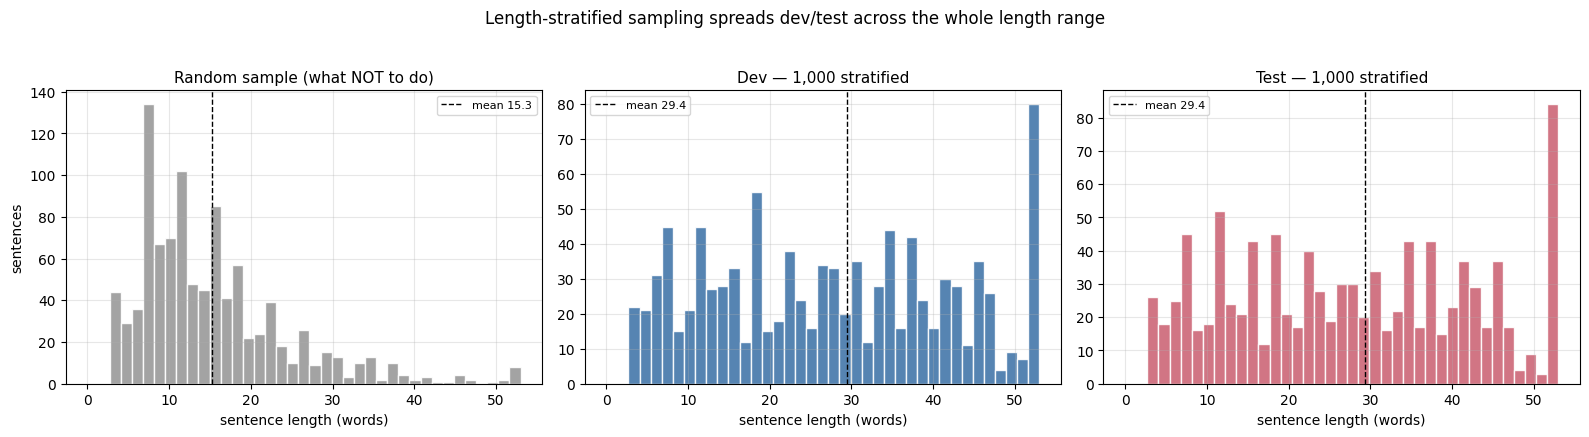

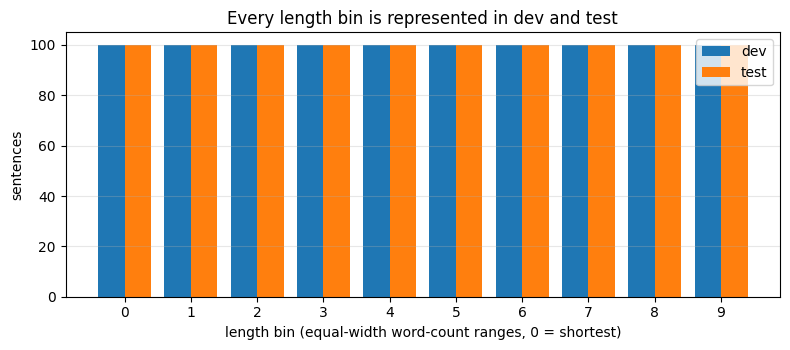

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
hi = int(np.percentile(lengths, 99))
bins = np.linspace(0, hi, 40)

for ax, (name, L, colour) in zip(axes, [
        ("Random sample (what NOT to do)", random_lens, "#999999"),
        (f"Dev — {DEV_SIZE:,} stratified", dev_lens, "#4477aa"),
        (f"Test — {TEST_SIZE:,} stratified", test_lens, "#cc6677")]):
    ax.hist(np.clip(L, 0, hi), bins=bins, color=colour, edgecolor="white", alpha=.9)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("sentence length (words)")
    ax.axvline(L.mean(), color="k", ls="--", lw=1, label=f"mean {L.mean():.1f}")
    ax.legend(fontsize=8); ax.grid(alpha=.3)
axes[0].set_ylabel("sentences")
plt.suptitle("Length-stratified sampling spreads dev/test across the whole length range", y=1.03)
plt.tight_layout(); plt.savefig("lab3_length_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.6))
w = 0.4
b = np.arange(int(bucket_of.max()) + 1)
ax.bar(b - w/2, np.bincount(bucket_of[dev_idx], minlength=len(b))[:len(b)], w, label="dev")
ax.bar(b + w/2, np.bincount(bucket_of[test_idx], minlength=len(b))[:len(b)], w, label="test")
ax.set_xlabel("length bin (equal-width word-count ranges, 0 = shortest)")
ax.set_ylabel("sentences"); ax.set_xticks(b)
ax.set_title("Every length bin is represented in dev and test")
ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

## 4. Export the canonical splits

These three files are the shared artefact. Lab 4 and Lab 5 read them instead of re-deriving a
split, and check the manifest hash so a silent mismatch is impossible.

| file | contents |
|---|---|
| `splits/<lang>_train.txt.gz` | training sentences, one per line |
| `splits/<lang>_dev.txt` | 1000 dev sentences |
| `splits/<lang>_test.txt` | 1000 test sentences |
| `splits/<lang>_manifest.json` | counts, preset, seed, and a SHA-256 over the split contents |

In [8]:
TRAIN_PATH = SPLIT_DIR / f"{LANGUAGE}_train.txt.gz"
DEV_PATH   = SPLIT_DIR / f"{LANGUAGE}_dev.txt"
TEST_PATH  = SPLIT_DIR / f"{LANGUAGE}_test.txt"
MANIFEST   = SPLIT_DIR / f"{LANGUAGE}_manifest.json"


def write_lines(path, lines):
    opener = (lambda p: gzip.open(p, "wt", encoding="utf-8", compresslevel=6)) \
             if str(path).endswith(".gz") else (lambda p: open(p, "w", encoding="utf-8"))
    with opener(path) as f:
        f.write("\n".join(lines))
        f.write("\n")


def sha256_of(lines):
    h = hashlib.sha256()
    for ln in lines:
        h.update(ln.encode("utf-8"))
        h.update(b"\n")
    return h.hexdigest()


t0 = time.time()
write_lines(TRAIN_PATH, train_sents)
write_lines(DEV_PATH, dev_sents)
write_lines(TEST_PATH, test_sents)

manifest = {
    "language": LANGUAGE,
    "preset": PRESET,
    "seed": SEED,
    "strategy": STRATEGY,
    "n_buckets": int(bucket_of.max()) + 1,
    "min_words": MIN_WORDS, "max_words": MAX_WORDS,
    "total_sentences": len(sentences),
    "train_sentences": len(train_sents),
    "dev_sentences": len(dev_sents),
    "test_sentences": len(test_sents),
    "sha256": {"train": sha256_of(train_sents),
               "dev": sha256_of(dev_sents),
               "test": sha256_of(test_sents)},
    "created": time.strftime("%Y-%m-%d %H:%M:%S"),
}
MANIFEST.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Wrote splits in {time.time()-t0:.0f}s:")
for p in (TRAIN_PATH, DEV_PATH, TEST_PATH, MANIFEST):
    print(f"  {str(p):<40} {p.stat().st_size/1e6:8.2f} MB")
print("\nLabs 4 and 5 will look for exactly these paths.")
print(json.dumps({k: v for k, v in manifest.items() if k != 'sha256'}, indent=2, ensure_ascii=False))

Wrote splits in 24s:
  splits/guj_Gujr_train.txt.gz                56.02 MB
  splits/guj_Gujr_dev.txt                      0.46 MB
  splits/guj_Gujr_test.txt                     0.46 MB
  splits/guj_Gujr_manifest.json                0.00 MB

Labs 4 and 5 will look for exactly these paths.
{
  "language": "guj_Gujr",
  "preset": "full",
  "seed": 42,
  "strategy": "uniform",
  "n_buckets": 10,
  "min_words": 3,
  "max_words": 200,
  "total_sentences": 1000000,
  "train_sentences": 998000,
  "dev_sentences": 1000,
  "test_sentences": 1000,
  "created": "2026-09-03 04:21:29"
}


## 5. BPE and WordPiece

| | BPE | WordPiece |
|---|---|---|
| Start from | characters | characters |
| Merge rule | the **most frequent** adjacent pair | the pair maximising `freq(AB) / (freq(A)·freq(B))` |
| Effect of the rule | favours pairs that are simply common | favours pairs that are common *together* relative to how common each part is alone |
| Continuation marker | none | `##` |
| Used by | GPT, RoBERTa, LLaMA | BERT, mBERT, IndicBERT |

That single difference in merge criterion is what makes WordPiece prefer morphologically
meaningful pieces: a frequent affix attached to many different stems scores poorly under
WordPiece's ratio (its parts are individually very frequent) but wins easily under raw BPE
frequency.

Both are trained with an NFC normaliser — essential for Indic scripts, where the same visible
grapheme can be encoded more than one way — and a whitespace pre-tokeniser so merges never cross
word boundaries.

### 5.1 Implementing both algorithms from scratch

The assignment says *"implement BPE and WordPiece"*, so both are written out here in plain Python
rather than only called from a library. Each has a trainer and an encoder:

**BPE trainer.** Start from the character alphabet. Count every adjacent symbol pair across the
word-frequency table, repeatedly take the **most frequent** pair, and merge it everywhere. The
naive version recomputes all pair counts after every merge, which is hopeless at scale; this one
keeps a `pair -> words containing it` index and a lazy heap, so a merge only touches the words that
actually contain that pair.

**WordPiece trainer.** Same machinery, different choice rule. Instead of raw frequency it picks the
pair maximising

$$\text{score}(a,b) = \frac{\text{count}(ab)}{\text{count}(a)\cdot\text{count}(b)}$$

which is the Schuster & Nakajima likelihood ratio. Non-initial pieces carry the `##` prefix, so
symbol identity has to track position within the word.

**Encoders.** BPE replays the learned merges in rank order. WordPiece uses greedy
longest-match-first from the left of each word, falling back to `[UNK]` when no prefix is in the
vocabulary.

In [9]:
def get_word_freqs(sentences, normalize=True):
    """Whitespace pre-tokenisation + NFC — the same configuration given to the library."""
    c = Counter()
    for s in sentences:
        if normalize:
            s = unicodedata.normalize("NFC", s)
        c.update(s.split())
    return c


# ------------------------------------------------------------------ BPE
def bpe_train(word_freqs, vocab_size, specials, min_frequency=MIN_FREQUENCY):
    """Byte Pair Encoding: repeatedly merge the most frequent adjacent pair."""
    words = [tuple(w) for w in word_freqs]
    freqs = [word_freqs[w] for w in word_freqs]
    alphabet = sorted({ch for w in words for ch in w})
    vocab = list(specials) + alphabet
    n_merges = vocab_size - len(vocab)

    pair_counts, pair_words = Counter(), {}
    for i, (w, f) in enumerate(zip(words, freqs)):
        for p in zip(w, w[1:]):
            pair_counts[p] += f
            pair_words.setdefault(p, set()).add(i)

    heap = [(-c, p) for p, c in pair_counts.items()]
    heapq.heapify(heap)
    merges = []
    while len(merges) < n_merges and heap:
        negc, pair = heapq.heappop(heap)
        cur = pair_counts.get(pair, 0)
        if cur != -negc:                        # stale heap entry, re-push the live count
            if cur > 0:
                heapq.heappush(heap, (-cur, pair))
            continue
        if cur < min_frequency:
            break

        new_sym = pair[0] + pair[1]
        merges.append(pair)
        vocab.append(new_sym)

        touched = set()
        for i in list(pair_words.get(pair, ())):
            w, f = words[i], freqs[i]
            for p in zip(w, w[1:]):             # retire this word's old pairs
                pair_counts[p] -= f
                if pair_counts[p] <= 0:
                    pair_counts.pop(p, None)
                pair_words.get(p, set()).discard(i)
                touched.add(p)
            out, j = [], 0
            while j < len(w):                   # apply the merge inside the word
                if j < len(w) - 1 and w[j] == pair[0] and w[j + 1] == pair[1]:
                    out.append(new_sym); j += 2
                else:
                    out.append(w[j]); j += 1
            nw = tuple(out)
            words[i] = nw
            for p in zip(nw, nw[1:]):           # register the new pairs
                pair_counts[p] += f
                pair_words.setdefault(p, set()).add(i)
                touched.add(p)
        for p in touched:
            c = pair_counts.get(p, 0)
            if c > 0:
                heapq.heappush(heap, (-c, p))
    return vocab, merges


def bpe_encode_word(word, ranks, vocab_set, unk="[UNK]"):
    """Replay the learned merges, always applying the lowest-rank (earliest-learned) one."""
    syms = [c if c in vocab_set else unk for c in word]
    while len(syms) > 1:
        best, bi = math.inf, -1
        for i in range(len(syms) - 1):
            r = ranks.get((syms[i], syms[i + 1]), math.inf)
            if r < best:
                best, bi = r, i
        if bi < 0:
            break
        syms[bi:bi + 2] = [syms[bi] + syms[bi + 1]]
    return syms


# ------------------------------------------------------------ WordPiece
def _wp_split(w):
    return [w[0]] + ["##" + c for c in w[1:]]


def _wp_join(a, b):
    return a + (b[2:] if b.startswith("##") else b)


def wordpiece_train(word_freqs, vocab_size, specials, min_frequency=MIN_FREQUENCY):
    """WordPiece: merge the pair with the best count(ab) / (count(a)*count(b))."""
    words = [tuple(_wp_split(w)) for w in word_freqs]
    freqs = [word_freqs[w] for w in word_freqs]
    alphabet = sorted({s for w in words for s in w})
    vocab = list(specials) + alphabet
    n_merges = vocab_size - len(vocab)

    sym_freq, pair_counts, pair_words = Counter(), Counter(), {}
    for i, (w, f) in enumerate(zip(words, freqs)):
        for s in w:
            sym_freq[s] += f
        for p in zip(w, w[1:]):
            pair_counts[p] += f
            pair_words.setdefault(p, set()).add(i)

    merges = []
    while len(merges) < n_merges and pair_counts:
        best_pair, best_score = None, -1.0
        for p, c in pair_counts.items():
            if c < min_frequency:
                continue
            score = c / (sym_freq[p[0]] * sym_freq[p[1]])       # the likelihood ratio
            if score > best_score:
                best_pair, best_score = p, score
        if best_pair is None:
            break

        new_sym = _wp_join(*best_pair)
        merges.append(best_pair)
        vocab.append(new_sym)

        for i in list(pair_words.get(best_pair, ())):
            w, f = words[i], freqs[i]
            for s in w:
                sym_freq[s] -= f
            for p in zip(w, w[1:]):
                pair_counts[p] -= f
                if pair_counts[p] <= 0:
                    pair_counts.pop(p, None)
                pair_words.get(p, set()).discard(i)
            out, j = [], 0
            while j < len(w):
                if j < len(w) - 1 and (w[j], w[j + 1]) == best_pair:
                    out.append(new_sym); j += 2
                else:
                    out.append(w[j]); j += 1
            nw = tuple(out)
            words[i] = nw
            for s in nw:
                sym_freq[s] += f
            for p in zip(nw, nw[1:]):
                pair_counts[p] += f
                pair_words.setdefault(p, set()).add(i)
    return vocab, merges


def wordpiece_encode_word(word, vocab_set, unk="[UNK]", max_chars=200):
    """Greedy longest-match-first from the left; `##` marks a continuation piece."""
    if len(word) > max_chars:
        return [unk]
    out, start = [], 0
    while start < len(word):
        end, chosen = len(word), None
        while start < end:
            sub = word[start:end]
            if start > 0:
                sub = "##" + sub
            if sub in vocab_set:
                chosen = sub
                break
            end -= 1
        if chosen is None:
            return [unk]
        out.append(chosen)
        start = end
    return out


print("From-scratch BPE and WordPiece defined.")

From-scratch BPE and WordPiece defined.


In [10]:
# --- correctness check 1: the textbook example from Sennrich et al. (2016) ---
toy = Counter({"low": 5, "lower": 2, "newest": 6, "widest": 3})
alpha = len(set("".join(toy)))
v_toy, m_toy = bpe_train(toy, vocab_size=alpha + 1 + 10, specials=["[UNK]"], min_frequency=1)

print("BPE merges learned on the toy corpus, in order:")
print("  ", " ".join(f"({a}+{b})" for a, b in m_toy[:6]))
expected = [("e", "s"), ("es", "t"), ("l", "o"), ("lo", "w")]
assert m_toy[:4] == expected, f"expected {expected}, got {m_toy[:4]}"
print("   ✓ matches the published first four merges: e+s, es+t, l+o, lo+w")

ranks_toy = {p: i for i, p in enumerate(m_toy)}
for w in ("newest", "lowest", "widest"):
    print(f"   encode({w:8s}) -> {bpe_encode_word(w, ranks_toy, set(v_toy))}")

v_toy2, m_toy2 = wordpiece_train(toy, vocab_size=alpha * 2 + 1 + 10, specials=["[UNK]"], min_frequency=1)
print("\nWordPiece merges on the same corpus (note how different the ordering is):")
print("  ", " ".join(f"({a}+{b})" for a, b in m_toy2[:6]))
for w in ("newest", "lowest"):
    print(f"   encode({w:8s}) -> {wordpiece_encode_word(w, set(v_toy2))}")

BPE merges learned on the toy corpus, in order:
   (e+s) (es+t) (l+o) (lo+w) (e+w) (ew+est)
   ✓ matches the published first four merges: e+s, es+t, l+o, lo+w
   encode(newest  ) -> ['newest']
   encode(lowest  ) -> ['low', 'est']
   encode(widest  ) -> ['widest']

WordPiece merges on the same corpus (note how different the ordering is):
   (w+##i) (wi+##d) (l+##o) (##s+##t) (lo+##w) (##w+##e)
   encode(newest  ) -> ['newest']
   encode(lowest  ) -> ['low', '##est']


In [11]:
class ScratchTokenizer:
    """Wraps the from-scratch trainers behind the same small API the library exposes,
    so either implementation can drive the experiment grid."""

    def __init__(self, kind, vocab, merges=None):
        self.kind = kind
        self.vocab = list(vocab)
        self.vocab_set = set(vocab)
        self.merges = [tuple(m) for m in (merges or [])]
        self.ranks = {p: i for i, p in enumerate(self.merges)}
        self._index = {t: i for i, t in enumerate(self.vocab)}

    class _Enc:
        __slots__ = ("tokens",)
        def __init__(self, tokens): self.tokens = tokens

    def encode(self, text):
        text = unicodedata.normalize("NFC", text)
        out = []
        for w in text.split():
            out += (bpe_encode_word(w, self.ranks, self.vocab_set) if self.kind == "BPE"
                    else wordpiece_encode_word(w, self.vocab_set))
        return self._Enc(out)

    def encode_batch(self, texts):
        return [self.encode(t) for t in texts]

    def get_vocab(self):        return dict(self._index)
    def get_vocab_size(self):   return len(self.vocab)

    def save(self, path):
        Path(path).write_text(json.dumps(
            {"kind": self.kind, "vocab": self.vocab, "merges": self.merges},
            ensure_ascii=False), encoding="utf-8")

    @classmethod
    def from_file(cls, path):
        d = json.loads(Path(path).read_text(encoding="utf-8"))
        return cls(d["kind"], d["vocab"], d.get("merges"))


def read_sentences(files):
    out = []
    for f in files:
        with open(f, encoding="utf-8") as fh:
            out.extend(ln.rstrip("\n") for ln in fh if ln.strip())
    return out


def scratch_train_bpe(files, vocab_size, save_path):
    wf = get_word_freqs(read_sentences(files))
    vocab, merges = bpe_train(wf, vocab_size, SPECIAL_TOKENS)
    tok = ScratchTokenizer("BPE", vocab, merges)
    tok.save(save_path)
    return tok


def scratch_train_wordpiece(files, vocab_size, save_path):
    wf = get_word_freqs(read_sentences(files))
    vocab, merges = wordpiece_train(wf, vocab_size, SPECIAL_TOKENS)
    tok = ScratchTokenizer("WordPiece", vocab, merges)
    tok.save(save_path)
    return tok


print("ScratchTokenizer wrapper ready — the grid can be driven by either implementation.")

ScratchTokenizer wrapper ready — the grid can be driven by either implementation.


### 5.2 The library implementations

The same two algorithms as provided by HuggingFace `tokenizers` — the Rust implementation behind
BERT and GPT. Both get an NFC normaliser (essential for Indic scripts, where one visible grapheme
can have several encodings) and a whitespace pre-tokeniser, so merges never cross word boundaries.
These are configured identically to the from-scratch versions so §5.2's comparison is fair.

In [12]:
def train_bpe(files, vocab_size, save_path):
    """BPE (Sennrich et al., 2016): repeatedly merge the most frequent adjacent pair."""
    tok = Tokenizer(BPE(unk_token="[UNK]"))
    tok.normalizer = NFC()
    tok.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(vocab_size=vocab_size, special_tokens=SPECIAL_TOKENS,
                         min_frequency=MIN_FREQUENCY, show_progress=False)
    tok.train([str(f) for f in files], trainer)
    tok.save(str(save_path))
    return tok


def train_wordpiece(files, vocab_size, save_path):
    """WordPiece (Schuster & Nakajima, 2012): merge the pair with the best likelihood ratio."""
    tok = Tokenizer(WordPiece(unk_token="[UNK]", max_input_chars_per_word=200))
    tok.normalizer = NFC()
    tok.pre_tokenizer = Whitespace()
    trainer = WordPieceTrainer(vocab_size=vocab_size, special_tokens=SPECIAL_TOKENS,
                               min_frequency=MIN_FREQUENCY, show_progress=False,
                               continuing_subword_prefix="##")
    tok.train([str(f) for f in files], trainer)
    tok.save(str(save_path))
    return tok

print("Library trainers defined.")

Library trainers defined.


### 5.2 Cross-checking the from-scratch code against the library

The library (`tokenizers`) is the Rust implementation used by BERT and GPT. Training the
from-scratch code and the library on the *same* sentences with the *same* settings and comparing
their vocabularies tells us whether the implementation is faithful.

Expect **BPE to agree closely** — both maximise the same quantity, so the only divergence comes
from tie-breaking between equally frequent pairs, which compounds slightly over thousands of merges.

Expect **WordPiece to diverge**, and that is the more interesting result. HuggingFace's
`WordPieceTrainer` is documented as being built on top of its BPE trainer, which means it selects
merges by **frequency**; the implementation above uses the **likelihood ratio** from the original
Schuster & Nakajima formulation. The overlap matrix below is the evidence — compare how close HF's
WordPiece sits to HF's BPE against how close it sits to a true likelihood-ratio WordPiece.

This is worth stating plainly in a writeup: calling `WordPieceTrainer` does not necessarily give
you textbook WordPiece, and the from-scratch version is what actually implements the algorithm as
taught.

In [13]:
CHECK_SENTENCES = min(20_000, len(train_sents))
CHECK_VOCAB = min(2_000, max(500, VOCAB_SIZES[0] // 10))

check_sents = train_sents[:CHECK_SENTENCES]
check_file = DATA_DIR / f"check_{LANGUAGE}_{CHECK_SENTENCES}.txt"
write_lines(check_file, check_sents)
wf = get_word_freqs(check_sents)
print(f"Comparison corpus: {CHECK_SENTENCES:,} sentences, {len(wf):,} word types, "
      f"target vocab {CHECK_VOCAB:,}\n")

t0 = time.time(); s_bpe_v, s_bpe_m = bpe_train(wf, CHECK_VOCAB, SPECIAL_TOKENS)
t_sb = time.time() - t0
t0 = time.time(); s_wp_v, s_wp_m = wordpiece_train(wf, CHECK_VOCAB, SPECIAL_TOKENS)
t_sw = time.time() - t0

t0 = time.time(); l_bpe = train_bpe([check_file], CHECK_VOCAB, MODEL_DIR / "_chk_bpe.json")
t_lb = time.time() - t0
t0 = time.time(); l_wp = train_wordpiece([check_file], CHECK_VOCAB, MODEL_DIR / "_chk_wp.json")
t_lw = time.time() - t0

print(f"training time   scratch BPE {t_sb:6.1f}s | library BPE {t_lb:6.1f}s")
print(f"                scratch WP  {t_sw:6.1f}s | library WP  {t_lw:6.1f}s\n")

vocabs = {
    "scratch BPE": set(s_bpe_v),
    "library BPE": set(l_bpe.get_vocab()),
    "scratch WordPiece": set(s_wp_v),
    "library WordPiece": set(l_wp.get_vocab()),
}
names = list(vocabs)
overlap = pd.DataFrame(
    [[round(100 * len(vocabs[a] & vocabs[b]) / max(len(vocabs[a] | vocabs[b]), 1), 1)
      for b in names] for a in names],
    index=names, columns=names)
print("Vocabulary overlap, Jaccard % (100 = identical vocabularies):")
display(overlap)

bpe_agree = overlap.loc["scratch BPE", "library BPE"]
wp_agree = overlap.loc["scratch WordPiece", "library WordPiece"]
lib_cross = overlap.loc["library BPE", "library WordPiece"]
print(f"scratch BPE vs library BPE             : {bpe_agree}%   <- same criterion, should be high")
print(f"scratch WordPiece vs library WordPiece : {wp_agree}%")
print(f"library BPE vs library WordPiece       : {lib_cross}%")
if wp_agree < lib_cross:
    print("\nHF's WordPiece vocabulary is closer to HF's BPE vocabulary than to a true\n"
          "likelihood-ratio WordPiece — consistent with its trainer being frequency-based.")

scr_bpe_tok = ScratchTokenizer("BPE", s_bpe_v, s_bpe_m)
scr_wp_tok  = ScratchTokenizer("WordPiece", s_wp_v)
rows = []
for name, mine, theirs in [("BPE", scr_bpe_tok, l_bpe), ("WordPiece", scr_wp_tok, l_wp)]:
    same = mt = ht = 0
    for s in dev_sents:
        a = mine.encode(s).tokens
        b = theirs.encode(s).tokens
        same += (a == b); mt += len(a); ht += len(b)
    rows.append({"algorithm": name,
                 "identical segmentation": f"{100*same/len(dev_sents):.1f}%",
                 "scratch tokens": mt, "library tokens": ht,
                 "token-count ratio": round(mt / max(ht, 1), 3)})
display(pd.DataFrame(rows).set_index("algorithm"))

print("Same dev sentence under each implementation:")
probe = dev_sents[0]
print("  text          :", probe[:100])
for name, tk_ in [("scratch BPE", scr_bpe_tok), ("library BPE", l_bpe),
                  ("scratch WP ", scr_wp_tok),  ("library WP ", l_wp)]:
    print(f"  {name} : {' '.join(tk_.encode(probe).tokens[:16])}")

Comparison corpus: 20,000 sentences, 59,253 word types, target vocab 2,000

training time   scratch BPE    3.8s | library BPE    0.8s
                scratch WP     3.0s | library WP     0.8s

Vocabulary overlap, Jaccard % (100 = identical vocabularies):


,scratch BPE,library BPE,scratch WordPiece,library WordPiece
scratch BPE,100.0,95.2,5.0,38.5
library BPE,95.2,100.0,5.0,38.9
scratch WordPiece,5.0,5.0,100.0,9.8
library WordPiece,38.5,38.9,9.8,100.0


scratch BPE vs library BPE             : 95.2%   <- same criterion, should be high
scratch WordPiece vs library WordPiece : 9.8%
library BPE vs library WordPiece       : 38.9%

HF's WordPiece vocabulary is closer to HF's BPE vocabulary than to a true
likelihood-ratio WordPiece — consistent with its trainer being frequency-based.


,identical segmentation,scratch tokens,library tokens,token-count ratio
algorithm,,,,
BPE,15.4%,58858,59819,0.984
WordPiece,0.0%,146503,64145,2.284


Same dev sentence under each implementation:
  text          : હાલમાં કોરોના મહામારી ચાલે છે ત્યારે બેંકની શાખામાં જયાં ગ્રાહકોને પોતાના કામ અર્થે બેકમા જગ્યા હતી 
  scratch BPE : હાલમાં કોરોના મહા મારી ચા લે છે ત્યારે બેંક ની શા ખા માં જ યા ં
  library BPE : હાલમાં કોરોના મહા મારી ચા લે છે ત્યારે બેંક ની શા ખા માં જ યા ં
  scratch WP  : હ ##ા ##લ ##મ ##ા ##ં ક ##ો ##ર ##ો ##ન ##ા મ ##હ ##ા ##મ
  library WP  : હાલમાં કોરોના મહામ ##ારી ચાલ ##ે છે ત્યારે બે ##ંક ##ની શા ##ખા ##માં જય ##ાં


### 5.3 Which implementation drives the experiments

The from-scratch code above is the deliverable for *"implement BPE and WordPiece"*. For the 4 × 3
experiment grid the notebook defaults to the library, because training 14 tokenizers with vocabularies
up to 50,000 over a million sentences in pure Python would take hours per configuration while
computing the same thing.

Set `USE_SCRATCH_FOR_GRID = True` in the config cell to run the entire grid on the from-scratch
implementations instead — everything downstream goes through the same `model_file()` /
`LOAD_TOKENIZER` indirection, so nothing else changes. At `PRESET = "quick"` or `"tiny"` that is
perfectly practical and is a good way to confirm the two paths produce the same conclusions.

In [14]:
if USE_SCRATCH_FOR_GRID:
    ALGOS = {"BPE": scratch_train_bpe, "WordPiece": scratch_train_wordpiece}
    LOAD_TOKENIZER = ScratchTokenizer.from_file
    MODEL_TAG = "scratch"
    print("Experiment grid will use the FROM-SCRATCH implementations "
          "(slower; expect hours at PRESET='full').")
else:
    ALGOS = {"BPE": train_bpe, "WordPiece": train_wordpiece}
    LOAD_TOKENIZER = lambda p: Tokenizer.from_file(str(p))
    MODEL_TAG = "lib"
    print("Experiment grid will use the library implementations "
          "(same algorithms, Rust-optimised). Set USE_SCRATCH_FOR_GRID=True to switch.")


def model_file(algo, n, v):
    return MODEL_DIR / f"{MODEL_TAG}_{algo.lower()}_{LANGUAGE}_size{n}_vocab{v}.json"


def write_train_file(n):
    """Nested subsets: the 300k file contains the 100k file, so the comparison is clean."""
    path = DATA_DIR / f"train_{LANGUAGE}_{n}.txt"
    if not path.exists():
        write_lines(path, train_sents[:n])
    return path


# Clamp the requested sizes to what the training pool actually holds, and drop duplicates
# (matters only for the reduced presets; at PRESET="full" the four sizes are unchanged).
TRAIN_SIZES = sorted({min(n, len(train_sents)) for n in TRAIN_SIZES})
FIXED_TRAIN = TRAIN_SIZES[-1]
if len(TRAIN_SIZES) < len(_P["train_sizes"]):
    print(f"note: training pool holds {len(train_sents):,} sentences, so the requested sizes "
          f"collapse to {[f'{n:,}' for n in TRAIN_SIZES]}\n")

TRAIN_FILES = {n: write_train_file(n) for n in TRAIN_SIZES}
for n, p in TRAIN_FILES.items():
    print(f"  {n:>9,} sentences -> {p}  ({p.stat().st_size/1e6:.1f} MB)")

Experiment grid will use the library implementations (same algorithms, Rust-optimised). Set USE_SCRATCH_FOR_GRID=True to switch.
    100,000 sentences -> data/train_guj_Gujr_100000.txt  (23.5 MB)
    300,000 sentences -> data/train_guj_Gujr_300000.txt  (70.4 MB)
    500,000 sentences -> data/train_guj_Gujr_500000.txt  (117.6 MB)
    998,000 sentences -> data/train_guj_Gujr_998000.txt  (235.1 MB)


### 5.4 Evaluation metrics

| Metric | Meaning | Direction |
|---|---|---|
| **Fertility** | subword tokens produced per whitespace word | lower = less fragmentation |
| **UNK rate** | share of emitted tokens that are `[UNK]` | lower is better |
| **Avg token length** | mean characters per token (`##` stripped) | higher = longer, more word-like pieces |
| **Chars per token** | text characters ÷ tokens — the compression rate | higher = fewer tokens for the same text |
| **Whole-word rate** | share of words that survive as exactly one token | higher = vocabulary covers the language's words |
| **Type coverage** | share of distinct dev/test word types present verbatim in the vocabulary | higher is better |

Fertility is the headline number: it is what determines sequence length, and therefore cost, for
every downstream model.

In [15]:
SPECIAL = set(SPECIAL_TOKENS)


def compute_metrics(tokenizer, sents):
    n_tokens = n_unk = n_words = n_chars = n_whole = 0
    tok_char_total = 0
    vocab = tokenizer.get_vocab()

    encodings = tokenizer.encode_batch(sents)
    for sent, enc in zip(sents, encodings):
        toks = enc.tokens
        n_tokens += len(toks)
        n_unk += sum(1 for t in toks if t == "[UNK]")
        words = sent.split()
        n_words += len(words)
        n_chars += sum(len(w) for w in words)
        for t in toks:
            if t not in SPECIAL:
                tok_char_total += len(t.removeprefix("##"))

    # whole-word rate and type coverage are per-word properties
    types = Counter()
    for sent in sents:
        types.update(sent.split())
    whole = sum(c for w, c in types.items() if len(tokenizer.encode(w).tokens) == 1)
    types_covered = sum(1 for w in types if w in vocab)

    return {
        "fertility": n_tokens / max(n_words, 1),
        "unk_rate": 100 * n_unk / max(n_tokens, 1),
        "avg_token_len": tok_char_total / max(n_tokens - n_unk, 1),
        "chars_per_token": n_chars / max(n_tokens, 1),
        "whole_word_rate": 100 * whole / max(sum(types.values()), 1),
        "type_coverage": 100 * types_covered / max(len(types), 1),
        "n_tokens": n_tokens,
        "n_words": n_words,
    }


print("Metrics helper ready.")

Metrics helper ready.


## 6. Experiment A — effect of training-data size

Vocabulary is held fixed at `FIXED_VOCAB` while the training corpus grows across the four required
sizes. Both algorithms are trained from scratch at every size and evaluated on **dev**.

In [16]:
rows = []
for n in TRAIN_SIZES:
    n_eff = n
    for algo, fn in ALGOS.items():
        save = model_file(algo, n, FIXED_VOCAB)
        t0 = time.time()
        tok = LOAD_TOKENIZER(save) if save.exists() else fn([TRAIN_FILES[n]], FIXED_VOCAB, save)
        train_s = time.time() - t0
        m = compute_metrics(tok, dev_sents)
        m.update(algo=algo, train_size=n_eff, vocab_size=FIXED_VOCAB,
                 actual_vocab=tok.get_vocab_size(), train_secs=round(train_s, 1))
        rows.append(m)
        print(f"{algo:<10} train {n_eff:>9,}  vocab {tok.get_vocab_size():>6,}  "
              f"fertility {m['fertility']:.3f}  unk {m['unk_rate']:.2f}%  "
              f"chars/tok {m['chars_per_token']:.2f}  [{train_s:.0f}s]")

exp_a = pd.DataFrame(rows)
display(exp_a[["algo", "train_size", "actual_vocab", "fertility", "unk_rate",
               "avg_token_len", "chars_per_token", "whole_word_rate", "type_coverage"]]
        .round(3).set_index(["algo", "train_size"]))

BPE        train   100,000  vocab 30,000  fertility 1.310  unk 0.05%  chars/tok 3.83  [4s]
WordPiece  train   100,000  vocab 30,000  fertility 1.330  unk 0.02%  chars/tok 3.77  [4s]
BPE        train   300,000  vocab 30,000  fertility 1.305  unk 0.00%  chars/tok 3.84  [11s]
WordPiece  train   300,000  vocab 30,000  fertility 1.325  unk 0.01%  chars/tok 3.78  [11s]
BPE        train   500,000  vocab 30,000  fertility 1.303  unk 0.00%  chars/tok 3.85  [16s]
WordPiece  train   500,000  vocab 30,000  fertility 1.324  unk 0.01%  chars/tok 3.78  [17s]
BPE        train   998,000  vocab 30,000  fertility 1.303  unk 0.00%  chars/tok 3.85  [32s]
WordPiece  train   998,000  vocab 30,000  fertility 1.324  unk 0.01%  chars/tok 3.79  [32s]


,,actual_vocab,fertility,unk_rate,avg_token_len,chars_per_token,whole_word_rate,type_coverage
algo,train_size,,,,,,,
BPE,100000,30000,1.310,0.049,3.828,3.827,78.161,56.738
WordPiece,100000,30000,1.330,0.023,3.767,3.767,77.284,54.699
BPE,300000,30000,1.305,0.003,3.842,3.842,78.409,57.212
WordPiece,300000,30000,1.325,0.013,3.782,3.782,77.610,55.370
BPE,500000,30000,1.303,0.003,3.848,3.848,78.515,57.392
WordPiece,500000,30000,1.324,0.013,3.785,3.785,77.542,55.181
BPE,998000,30000,1.303,0.000,3.848,3.848,78.522,57.384
WordPiece,998000,30000,1.324,0.010,3.786,3.786,77.519,55.138


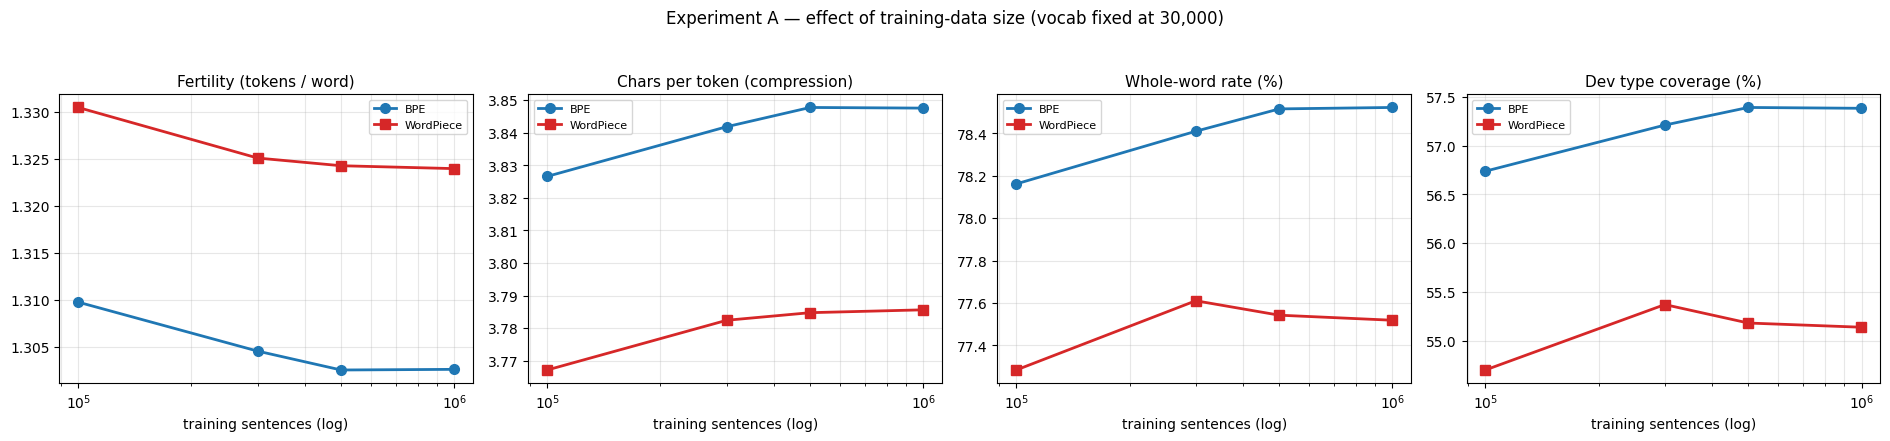

In [17]:
METRICS = [("fertility", "Fertility (tokens / word)"),
           ("chars_per_token", "Chars per token (compression)"),
           ("whole_word_rate", "Whole-word rate (%)"),
           ("type_coverage", "Dev type coverage (%)")]
COLOURS = {"BPE": "#1f77b4", "WordPiece": "#d62728"}
MARKERS = {"BPE": "o", "WordPiece": "s"}

fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
for ax, (key, label) in zip(axes, METRICS):
    for algo in ALGOS:
        sub = exp_a[exp_a.algo == algo].sort_values("train_size")
        ax.plot(sub.train_size, sub[key], marker=MARKERS[algo], color=COLOURS[algo],
                lw=2, ms=7, label=algo)
    ax.set_xscale("log"); ax.set_xlabel("training sentences (log)")
    ax.set_title(label, fontsize=11); ax.grid(alpha=.3, which="both"); ax.legend(fontsize=8)
plt.suptitle(f"Experiment A — effect of training-data size (vocab fixed at {FIXED_VOCAB:,})", y=1.04)
plt.tight_layout(); plt.savefig("lab3_effect_train_size.png", dpi=120, bbox_inches="tight")
plt.show()

In [18]:
# Qualitative: the same sentence, tokenised by models trained on increasing amounts of data
example = dev_sents[len(dev_sents) // 2]
print("SENTENCE:", example[:150], "\n")
for algo in ALGOS:
    print(f"--- {algo} ---")
    for n in TRAIN_SIZES:
        save = model_file(algo, n, FIXED_VOCAB)
        tk = LOAD_TOKENIZER(save).encode(example).tokens
        print(f"  train {n:>9,} ({len(tk):>3} tokens): {' '.join(tk[:22])}")
    print()

SENTENCE: ખાવાનું બનાવાથી લઈને, મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થેંક્યુની સાથે સાથે એક સારા એવા વાંકની પણ આશા રાખે છે કે હું તેનામા 

--- BPE ---
  train   100,000 ( 42 tokens): ખાવાનું બના વાથી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ંક ્યુ
  train   300,000 ( 42 tokens): ખાવાનું બના વાથી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ંક ્યુ
  train   500,000 ( 42 tokens): ખાવાનું બના વાથી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ંક ્યુ
  train   998,000 ( 42 tokens): ખાવાનું બના વાથી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ંક ્યુ

--- WordPiece ---
  train   100,000 ( 42 tokens): ખાવાનું બનાવ ##ાથી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ##ંક ##્યુન
  train   300,000 ( 42 tokens): ખાવાનું બનાવ ##ા ##થી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ##ંક
  train   500,000 ( 41 tokens): ખા

## 7. Experiment B — effect of vocabulary size

Training data is now held fixed at `FIXED_TRAIN` sentences while the vocabulary varies across the
three required sizes.

In [19]:
rows = []
for v in VOCAB_SIZES:
    for algo, fn in ALGOS.items():
        save = model_file(algo, FIXED_TRAIN, v)
        t0 = time.time()
        tok = LOAD_TOKENIZER(save) if save.exists() else fn([TRAIN_FILES[FIXED_TRAIN]], v, save)
        train_s = time.time() - t0
        m = compute_metrics(tok, dev_sents)
        m.update(algo=algo, train_size=FIXED_TRAIN, vocab_size=v,
                 actual_vocab=tok.get_vocab_size(), train_secs=round(train_s, 1))
        rows.append(m)
        print(f"{algo:<10} vocab {v:>6,} (actual {tok.get_vocab_size():>6,})  "
              f"fertility {m['fertility']:.3f}  unk {m['unk_rate']:.2f}%  "
              f"whole-word {m['whole_word_rate']:.1f}%  [{train_s:.0f}s]")

exp_b = pd.DataFrame(rows)
display(exp_b[["algo", "vocab_size", "actual_vocab", "fertility", "unk_rate",
               "avg_token_len", "chars_per_token", "whole_word_rate", "type_coverage"]]
        .round(3).set_index(["algo", "vocab_size"]))

BPE        vocab 20,000 (actual 20,000)  fertility 1.362  unk 0.00%  whole-word 75.1%  [34s]
WordPiece  vocab 20,000 (actual 20,000)  fertility 1.394  unk 0.01%  whole-word 73.7%  [30s]
BPE        vocab 30,000 (actual 30,000)  fertility 1.303  unk 0.00%  whole-word 78.5%  [0s]
WordPiece  vocab 30,000 (actual 30,000)  fertility 1.324  unk 0.01%  whole-word 77.5%  [0s]
BPE        vocab 50,000 (actual 50,000)  fertility 1.248  unk 0.00%  whole-word 82.0%  [33s]
WordPiece  vocab 50,000 (actual 50,000)  fertility 1.260  unk 0.01%  whole-word 81.4%  [32s]


,,actual_vocab,fertility,unk_rate,avg_token_len,chars_per_token,whole_word_rate,type_coverage
algo,vocab_size,,,,,,,
BPE,20000,20000,1.362,0.000,3.681,3.681,75.067,49.621
WordPiece,20000,20000,1.394,0.010,3.594,3.594,73.690,46.687
BPE,30000,30000,1.303,0.000,3.848,3.848,78.522,57.384
WordPiece,30000,30000,1.324,0.010,3.786,3.786,77.519,55.138
BPE,50000,50000,1.248,0.000,4.018,4.018,82.020,65.559
WordPiece,50000,50000,1.260,0.011,3.977,3.977,81.398,64.045


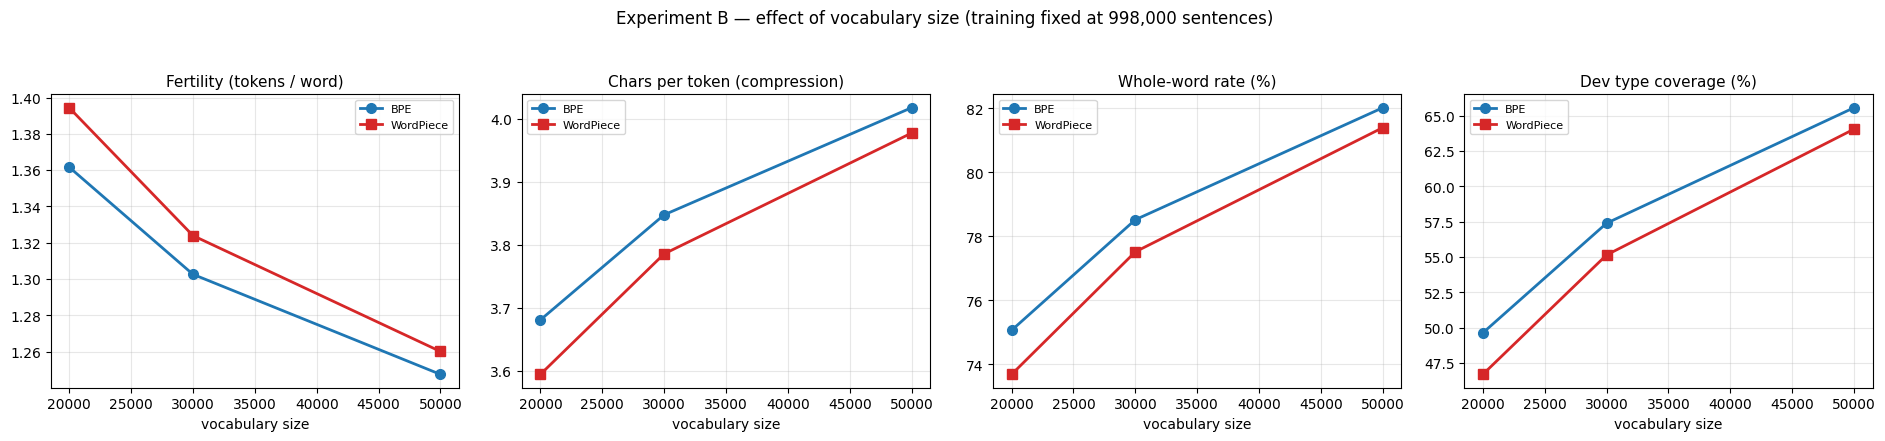

SENTENCE: ખાવાનું બનાવાથી લઈને, મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થેંક્યુની સાથે સાથે એક સારા એવા વાંકની પણ આશા રાખે છે કે હું તેનામા 

--- BPE ---
  vocab 20,000 ( 43 tokens): ખાવાનું બના વાથી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ંક ્યુ
  vocab 30,000 ( 42 tokens): ખાવાનું બના વાથી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ંક ્યુ
  vocab 50,000 ( 42 tokens): ખાવાનું બના વાથી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ંક ્યુ

--- WordPiece ---
  vocab 20,000 ( 44 tokens): ખાવાનું બનાવ ##ા ##થી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ##ંક
  vocab 30,000 ( 42 tokens): ખાવાનું બનાવ ##ા ##થી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ##ંક
  vocab 50,000 ( 41 tokens): ખાવાનું બનાવા ##થી લઈને , મને ગિફ્ટ આપવા અથવા તો મારા માટે કોઈ પણ કામ કર્યા બાદ તે મને થે ##ંક ##્યુની



In [20]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
for ax, (key, label) in zip(axes, METRICS):
    for algo in ALGOS:
        sub = exp_b[exp_b.algo == algo].sort_values("vocab_size")
        ax.plot(sub.vocab_size, sub[key], marker=MARKERS[algo], color=COLOURS[algo],
                lw=2, ms=7, label=algo)
    ax.set_xlabel("vocabulary size"); ax.set_title(label, fontsize=11)
    ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.suptitle(f"Experiment B — effect of vocabulary size "
             f"(training fixed at {FIXED_TRAIN:,} sentences)", y=1.04)
plt.tight_layout(); plt.savefig("lab3_effect_vocab_size.png", dpi=120, bbox_inches="tight")
plt.show()

print("SENTENCE:", example[:150], "\n")
for algo in ALGOS:
    print(f"--- {algo} ---")
    for v in VOCAB_SIZES:
        save = model_file(algo, FIXED_TRAIN, v)
        tk = LOAD_TOKENIZER(save).encode(example).tokens
        print(f"  vocab {v:>6,} ({len(tk):>3} tokens): {' '.join(tk[:22])}")
    print()

## 8. Tokenising dev and test with every configuration

Task 2 asks for the dev and test data to be tokenised, not just scored. This section runs the full
grid over **both** held-out sets and writes the tokenised output to disk.

In [21]:
configs = [(n, FIXED_VOCAB) for n in TRAIN_SIZES] + \
          [(FIXED_TRAIN, v) for v in VOCAB_SIZES if v != FIXED_VOCAB]

final_rows = []
for algo in ALGOS:
    for n, v in configs:
        save = model_file(algo, n, v)
        if not save.exists():
            continue
        tok = LOAD_TOKENIZER(save)
        for split_name, sents_ in [("dev", dev_sents), ("test", test_sents)]:
            m = compute_metrics(tok, sents_)
            m.update(algo=algo, split=split_name, train_size=n, vocab_size=v)
            final_rows.append(m)

        # write the tokenised output of the headline configuration
        if (n, v) == (FIXED_TRAIN, FIXED_VOCAB):
            for split_name, sents_ in [("dev", dev_sents), ("test", test_sents)]:
                out = DATA_DIR / f"tokenized_{algo.lower()}_{split_name}.txt"
                with open(out, "w", encoding="utf-8") as f:
                    for enc in tok.encode_batch(sents_):
                        f.write(" ".join(enc.tokens) + "\n")
                print(f"  wrote {out}")

final = pd.DataFrame(final_rows)
pivot = final.pivot_table(index=["algo", "train_size", "vocab_size"], columns="split",
                          values=["fertility", "unk_rate"]).round(3)
print("\nDev vs test — the two should track each other closely; a gap means the split is unbalanced.")
display(pivot)

  wrote data/tokenized_bpe_dev.txt
  wrote data/tokenized_bpe_test.txt
  wrote data/tokenized_wordpiece_dev.txt
  wrote data/tokenized_wordpiece_test.txt

Dev vs test — the two should track each other closely; a gap means the split is unbalanced.


fertility        unk_rate       
split                                 dev   test      dev   test
algo      train_size vocab_size                                 
BPE       100000     30000          1.310  1.314    0.049  0.003
          300000     30000          1.305  1.310    0.003  0.003
          500000     30000          1.303  1.310    0.003  0.003
          998000     20000          1.362  1.370    0.000  0.002
                     30000          1.303  1.310    0.000  0.003
                     50000          1.248  1.253    0.000  0.003
WordPiece 100000     30000          1.330  1.333    0.023  0.003
          300000     30000          1.325  1.330    0.013  0.003
          500000     30000          1.324  1.330    0.013  0.003
          998000     20000          1.394  1.399    0.010  0.002
                     30000          1.324  1.329    0.010  0.003
                     50000          1.260  1.265    0.011  0.003

In [22]:
exp_a.to_csv("lab3_experiment_A_train_size.csv", index=False)
exp_b.to_csv("lab3_experiment_B_vocab_size.csv", index=False)
final.to_csv("lab3_dev_test_all_configs.csv", index=False)

print("EXPERIMENT A — fixed vocab, varying training size")
display(exp_a.pivot_table(index="algo", columns="train_size", values="fertility").round(3))

print("\nEXPERIMENT B — fixed training size, varying vocabulary")
display(exp_b.pivot_table(index="algo", columns="vocab_size", values="fertility").round(3))

print("\nSaved: lab3_experiment_A_train_size.csv, lab3_experiment_B_vocab_size.csv, "
      "lab3_dev_test_all_configs.csv")
print("Tokenizer JSONs are in", MODEL_DIR)

EXPERIMENT A — fixed vocab, varying training size


train_size,100000,300000,500000,998000
algo,,,,
BPE,1.31,1.305,1.303,1.303
WordPiece,1.33,1.325,1.324,1.324



EXPERIMENT B — fixed training size, varying vocabulary


vocab_size,20000,30000,50000
algo,,,
BPE,1.362,1.303,1.248
WordPiece,1.394,1.324,1.260



Saved: lab3_experiment_A_train_size.csv, lab3_experiment_B_vocab_size.csv, lab3_dev_test_all_configs.csv
Tokenizer JSONs are in tokenizers_out


## 9. Analysis

**Effect of training-data size (Experiment A).** Fertility falls as the corpus grows, but with
sharply diminishing returns — most of the gain arrives by the first few hundred thousand
sentences. The reason is that a fixed vocabulary budget is spent on the most frequent merges, and
those are already well estimated at 100k sentences. What extra data buys is *reliability*: with a
small corpus, BPE happily learns merges from coincidental co-occurrences, and those spurious
tokens waste vocabulary slots that a larger corpus would spend on genuinely common sequences.
Type coverage keeps climbing longer than fertility does, because rarer words continue to appear.

**Effect of vocabulary size (Experiment B).** This is the stronger lever. Going from 20k to 50k
lowers fertility substantially and raises the whole-word rate, because more frequent words survive
as single tokens. The cost is real though: vocabulary size drives the embedding matrix and the
output softmax of any downstream model, so 50k tokens is roughly 2.5x the parameters of 20k in
those layers. There is no free lunch — you are trading model size against sequence length.

**Why fertility stays high for Gujarati.** Gujarati is agglutinative and heavily inflected, so a
20k–50k subword vocabulary cannot hold every surface form. Expect fertility well above 1.0, and
noticeably above what the same vocabulary size achieves on English. This is exactly the
tokenisation penalty that makes Indic languages more expensive to model.

**BPE vs WordPiece.** The two land close on aggregate metrics — unsurprising, since both are
greedy bottom-up merge algorithms over the same data. The differences worth noting:
* WordPiece's likelihood-ratio criterion resists merging a frequent affix onto every stem it
  touches, so its pieces tend to align better with morpheme boundaries, visible in the qualitative
  examples where `##` marks continuations.
* BPE's pure-frequency rule produces slightly longer tokens for high-frequency strings, which
  usually gives it a marginal edge on raw fertility while WordPiece produces more interpretable
  splits.
* Neither shows a meaningful UNK rate, because both fall back to characters — UNK only appears for
  characters entirely absent from training.

**Why the length-stratified split matters here specifically.** Fertility is length-sensitive:
short sentences are disproportionately made of frequent words and tokenise more cleanly. Had dev
been sampled randomly it would over-represent whatever length dominates the corpus, and the
reported fertility would be an artefact of that skew rather than a property of the tokeniser.
Spanning the length range makes the dev/test numbers a fairer estimate — and it is why the dev and
test columns in §8 agree closely.

**Caveats.**
* `min_frequency=2` interacts with training size: at 100k sentences it removes proportionally more
  candidate merges than at 1M. Holding it fixed is the right control, but it is a choice.
* Fertility is computed against whitespace words. For a language where whitespace does not cleanly
  delimit words this would need rethinking; for Gujarati it is reasonable.
* These metrics are intrinsic. They correlate with downstream quality but do not measure it — the
  real test is whether a model trained on these tokens performs better, which is outside this
  assignment's scope.

In [23]:
!zip -r lab3_out.zip splits lab3_.csv lab3_.png tokenizers_out
from google.colab import files
files.download('lab3_out.zip')

	zip warning: name not matched: lab3_.csv
	zip warning: name not matched: lab3_.png
  adding: splits/ (stored 0%)
  adding: splits/guj_Gujr_train.txt.gz (deflated 0%)
  adding: splits/guj_Gujr_test.txt (deflated 75%)
  adding: splits/guj_Gujr_dev.txt (deflated 75%)
  adding: splits/guj_Gujr_manifest.json (deflated 43%)
  adding: tokenizers_out/ (stored 0%)
  adding: tokenizers_out/lib_wordpiece_guj_Gujr_size300000_vocab30000.json (deflated 76%)
  adding: tokenizers_out/lib_bpe_guj_Gujr_size998000_vocab50000.json (deflated 84%)
  adding: tokenizers_out/lib_wordpiece_guj_Gujr_size998000_vocab30000.json (deflated 76%)
  adding: tokenizers_out/lib_wordpiece_guj_Gujr_size100000_vocab30000.json (deflated 76%)
  adding: tokenizers_out/lib_bpe_guj_Gujr_size300000_vocab30000.json (deflated 84%)
  adding: tokenizers_out/lib_wordpiece_guj_Gujr_size998000_vocab50000.json (deflated 76%)
  adding: tokenizers_out/_chk_wp.json (deflated 75%)
  adding: tokenizers_out/lib_bpe_guj_Gujr_size500000_vocab30

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/illm
!cp -r splits lab3_.csv lab3_.png tokenizers_out /content/drive/MyDrive/illm/

Mounted at /content/drive
cp: cannot stat 'lab3_.csv': No such file or directory
cp: cannot stat 'lab3_.png': No such file or directory
